In [13]:
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

plt.style.use('../src/plot.mplstyle')
mpl.rcParams['figure.dpi'] = 300

cm = 1/2.54

repo_root = os.path.abspath(os.path.join(os.getcwd(), "../src"))
sys.path.append(repo_root)
from df_gen import *


In [14]:
#df=pd.read_pickle('../data/xyz/df_rev1.pckl.gzip',compression="gzip")
df=pd.read_pickle('../data/xyz/df_npt_anneal_293K_10ps_-1_generated.pckl.gzip',compression="gzip")
df.columns

Index(['ase_atoms', 'nb_atoms', 'size', 'vol_per_atom', 'label', 'Category_2',
       'Category_color_2', 'mtp_energy', 'dE_mtp', 'mtp_at_E_NN', 'forces',
       'F_max', 'soap_sim_cSi', 'atomistic_soap_sim_cSi', 'CNA', 'ptm_cat'],
      dtype='object')

In [18]:
def scatter_hist(x, y, ax, ax_histx, ax_histy, colors, custom_cmap, label):
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    ax.scatter(x, y,c=colors, cmap=custom_cmap, label=label,  s=10, alpha=0.7, vmin=0, vmax=7)
    sns.histplot(x, binrange=[-0.02, 0.6], binwidth=0.02, kde=True, label=label, ax=ax_histx, color='#282828', stat='count', line_kws={'linewidth':1})
    sns.histplot(y=y, binrange=[0.38, 1.02], binwidth=0.02, kde=True, label=label, ax=ax_histy, color='#282828', stat='count', line_kws={'linewidth':1},  orientation='horizontal')
    

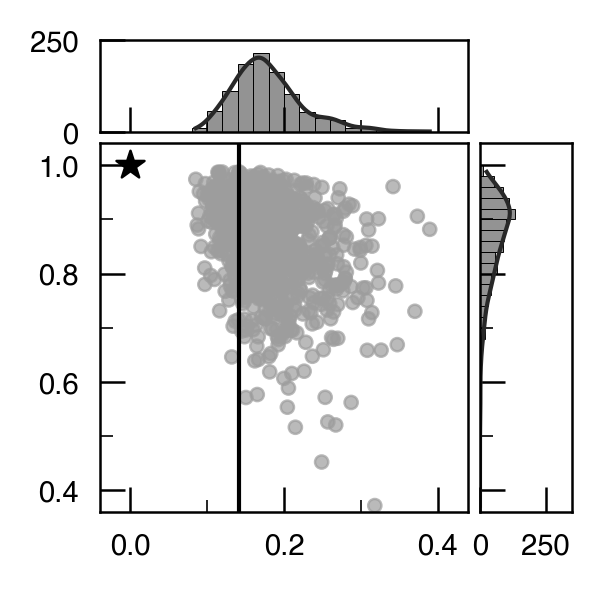

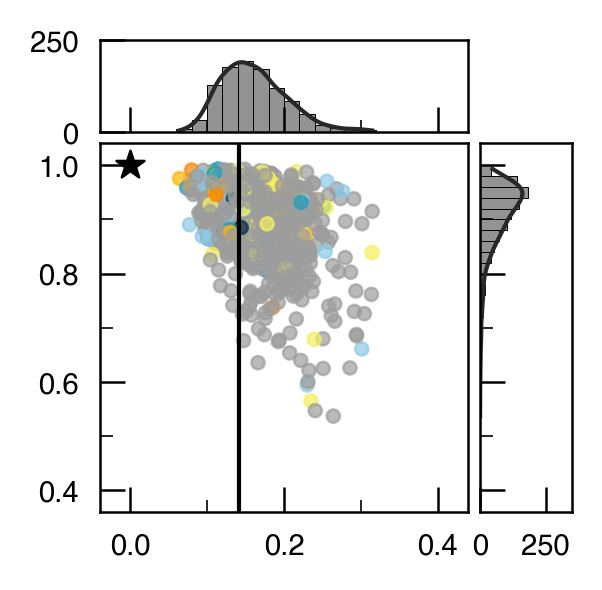

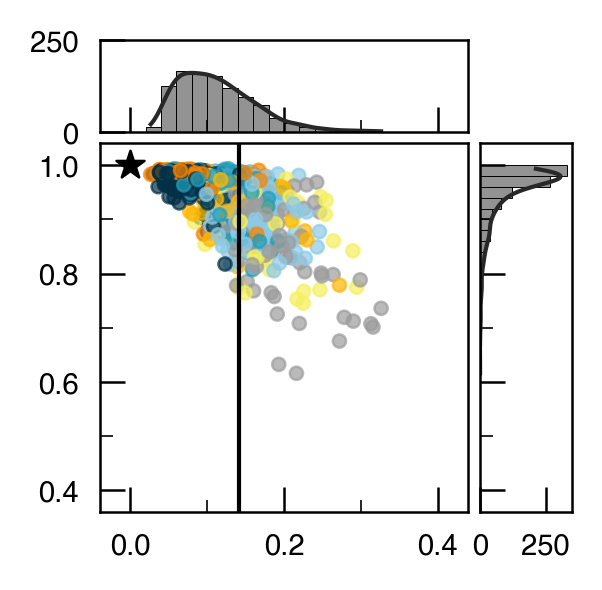

In [19]:
##### NN local atomic energy _ GAP
custom_colors=['#9D9D9D', '#023047', '#219EBC', '#8ECAE6', '#FB8500', '#FFB703', '#F5F05E'] # cmap for diamond environments
custom_cmap = mcolors.ListedColormap(custom_colors)

selec_strus=np.array((2491, 2576, 2604))
labels=['CRN', 'Paracrystalline - IV', 'Polycrystalline']

for item, label  in zip(selec_strus, labels):
    fig = plt.figure(figsize=(5*cm, 5*cm))
    gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4), left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.05, hspace=0.05)

    #Obtain x,y,colors
    soap_sim=df['atomistic_soap_sim_cSi'][item]
    soap_sim=soap_sim.flatten()
    dE_NN_mtp_df=df['mtp_at_E_NN'][item]
    colors =np.asarray(df['CNA'][item])
    
    # Create the Axes.
    ax = fig.add_subplot(gs[1, 0])

    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

    # Draw the scatter plot and marginals.
    scatter_hist(dE_NN_mtp_df, soap_sim, ax, ax_histx, ax_histy, colors, custom_cmap, label)
    ax.axvline(x = 0.142, color = 'k', linestyle = '-', linewidth=1)
    ax.scatter(0,1, marker='*', s=50, color='k')

    #Format scatter
    ax.set_xticks(np.arange(0,0.6,0.2))
    ax.set_xticks(np.arange(0.1,0.5,0.2), minor = True)
    ax.set_yticks(np.arange(0.4,1.2,0.2))
    ax.set_yticks(np.arange(0.5,1.1,0.2), minor = True)
    ax.set_xlim(left=-0.04, right=0.44)
    ax.set_ylim(bottom=0.36, top=1.04)

    ax_histy.set_xlabel('')
    ax_histy.set_xlim(right=350)

    ax_histx.set_ylabel('')
    ax_histx.set_ylim(top=250)

    #fig.tight_layout()

    